# Transfer Learning — the *fast* way

In notebook 21 we ran the **whole** VGG16 forward pass on every image, every epoch,
even though all of VGG was frozen. That's wasteful: the frozen layers produce the
*same* output for a given image every single time.

Here we do it the fast way instead:

1. Run each image through the frozen VGG feature extractor **exactly once**, and
   store the resulting 25088-dim vectors as `X_train` / `X_test`.
2. Train only a small `nn.Linear(D, 1)` head on those precomputed features.

That second step is just logistic regression on a fixed feature matrix, so each
epoch takes a fraction of a second instead of seconds.

**Note on the dataset:** the course uses Food-5K, but that download is dead
(`lazyprogrammer.me/course_files/Food-5K.zip` → 404, and the EPFL FTP backend
`grebvm2.epfl.ch` is unreachable). We use the ants-vs-bees set from PyTorch's own
transfer-learning tutorial — same shape of problem, already in `ImageFolder`
layout, ~45MB. This is the same dataset notebook 21 uses, so the two are directly
comparable.

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys, os
from glob import glob

In [2]:
!wget -nc https://download.pytorch.org/tutorial/hymenoptera_data.zip

File ‘hymenoptera_data.zip’ already there; not retrieving.



In [3]:
!unzip -qq -o hymenoptera_data.zip

Note: unlike notebook 21 there is only **one** transform, and it has no random
augmentation (no `RandomCrop`, no `RandomHorizontalFlip`, no `ColorJitter`).

Why do we only need one? Because we pass each image through VGG a single time and
cache the result. Random augmentation only helps if the model sees a *different*
version of the image on each epoch — but here the features are frozen after one
pass, so augmentation would just bake in one arbitrary distortion. The train and
test sets therefore get the exact same deterministic preprocessing.

In [4]:
# Note: normalize mean and std are standardized for ImageNet
transform = transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(
    'hymenoptera_data/train',
    transform=transform
)
test_dataset = datasets.ImageFolder(
    'hymenoptera_data/val',
    transform=transform
)

print(train_dataset.classes, '->', train_dataset.class_to_idx)

['ants', 'bees'] -> {'ants': 0, 'bees': 1}


In [6]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
)

In [7]:
# Define the pretrained model
try:
  vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
except AttributeError:
  # older torchvision versions
  vgg = models.vgg16(pretrained=True)

In [8]:
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

So the next part is also new. We only want the convolutional feature extractor —
`features` → `avgpool` → flatten — and we deliberately stop *before* VGG's own
`classifier`, since that ends in `Linear(4096, 1000)` for ImageNet's 1000 classes.
Flattening after `avgpool` gives us 512 × 7 × 7 = **25088** features per image.

In [9]:
class VGGFeatures(nn.Module):
  def __init__(self, vgg):
    super(VGGFeatures, self).__init__()
    self.vgg = vgg

  def forward(self, X):
    # note: use self.vgg (not the global `vgg`) so the module is self-contained
    # and follows whatever device .to() moved it to
    out = self.vgg.features(X)
    out = self.vgg.avgpool(out)
    out = out.view(out.size(0), -1) # flatten
    return out

In [10]:
vggf = VGGFeatures(vgg)

In [11]:
out = vggf(torch.rand(1, 3, 224, 224))
out.shape

torch.Size([1, 25088])

In [12]:
# Transform the data
Ntrain = len(train_dataset)
Ntest = len(test_dataset)
Ntrain, Ntest

(244, 153)

In [13]:
# Dimensionality
D = out.shape[1]
D

25088

In [14]:
X_train = np.zeros((Ntrain, D))
y_train = np.zeros((Ntrain, 1))
X_test = np.zeros((Ntest, D))
y_test = np.zeros((Ntest, 1))

In [15]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)
vggf.to(device)

mps


VGGFeatures(
  (vgg): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16)

In [16]:
# populate X_train and Y_train
i = 0
with torch.no_grad():
  for inputs, targets in train_loader:
    # move data to GPU
    inputs = inputs.to(device)

    # get output
    output = vggf(inputs)

    # size of the batch (may not always be batch_size)
    sz = len(output)

    # assign to X_train and y_train
    X_train[i:i + sz] = output.cpu().detach().numpy()
    y_train[i:i + sz] = targets.view(-1, 1).numpy()

    # increment i
    i += sz
    print(i)

128


244


On each iteration we can confirm that the number of samples in our new dataset is
equal to the original number of samples.

In [17]:
# populate X_test and Y_test
i = 0
with torch.no_grad():
  for inputs, targets in test_loader:
    # move data to GPU
    inputs = inputs.to(device)

    # get output
    output = vggf(inputs)

    # size of the batch (may not always be batch_size)
    sz = len(output)

    # assign to X_test and y_test
    X_test[i:i + sz] = output.cpu().detach().numpy()
    y_test[i:i + sz] = targets.view(-1, 1).numpy()

    # increment i
    i += sz
    print(i)

128


153


In [18]:
X_train.max(), X_train.min()

(np.float64(47.126220703125), np.float64(0.0))

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train2 = scaler.fit_transform(X_train)
X_test2 = scaler.transform(X_test)

In [20]:
# Try the built-in logistic regression

from sklearn.linear_model import LogisticRegression
# note: max_iter raised from the default 100 so lbfgs converges on 25088 features
logr = LogisticRegression(max_iter=1000)
logr.fit(X_train2, y_train.flatten())
print("train score:", logr.score(X_train2, y_train.flatten()))
print("test score:", logr.score(X_test2, y_test.flatten()))

train score: 1.0
test score: 0.9281045751633987


/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ankit/Workspace/Projects/ankit-github/A

In [21]:
# Do logistic regression in PyTorch
model = nn.Linear(D, 1)

In [22]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)
model.to(device)

mps


Linear(in_features=25088, out_features=1, bias=True)

In [23]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters())

In [24]:
# Make datasets
train_dataset2 = torch.utils.data.TensorDataset(
    torch.from_numpy(X_train2.astype(np.float32)),
    torch.from_numpy(y_train.astype(np.float32)),
)

test_dataset2 = torch.utils.data.TensorDataset(
    torch.from_numpy(X_test2.astype(np.float32)),
    torch.from_numpy(y_test.astype(np.float32)),
)

In [25]:
# Data loaders
batch_size = 128
train_loader2 = torch.utils.data.DataLoader(dataset=train_dataset2,
                                            batch_size=batch_size,
                                            shuffle=True)

test_loader2 = torch.utils.data.DataLoader(dataset=test_dataset2,
                                           batch_size=batch_size,
                                           shuffle=False)

In [26]:
def batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs):
  train_losses = np.zeros(epochs)
  test_losses = np.zeros(epochs)

  for it in range(epochs):
    t0 = datetime.now()
    train_loss = []
    for inputs, targets in train_loader:
      # move data to GPU
      inputs, targets = inputs.to(device), targets.to(device)

      # zero the parameter gradients
      optimizer.zero_grad()

      # Forward pass
      outputs = model(inputs)
      loss = criterion(outputs, targets)

      # Backward and optimize
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

    # Get train loss and test loss
    train_loss = np.mean(train_loss) # a little misleading

    test_loss = []
    for inputs, targets in test_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      test_loss.append(loss.item())
    test_loss = np.mean(test_loss)

    # Save losses
    train_losses[it] = train_loss
    test_losses[it] = test_loss

    dt = datetime.now() - t0
    print(f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, '
          f'Test Loss: {test_loss:.4f}, Duration: {dt}')

  return train_losses, test_losses

In [27]:
train_losses, test_losses = batch_gd(
    model,
    criterion,
    optimizer,
    train_loader2,
    test_loader2,
    epochs=10,
)

Epoch 1/10, Train Loss: 0.5532, Test Loss: 0.4836, Duration: 0:00:00.703550
Epoch 2/10, Train Loss: 0.0681, Test Loss: 0.5430, Duration: 0:00:00.014928
Epoch 3/10, Train Loss: 0.0202, Test Loss: 0.6141, Duration: 0:00:00.012277
Epoch 4/10, Train Loss: 0.0053, Test Loss: 0.6780, Duration: 0:00:00.011702
Epoch 5/10, Train Loss: 0.0023, Test Loss: 0.7319, Duration: 0:00:00.011551
Epoch 6/10, Train Loss: 0.0011, Test Loss: 0.7772, Duration: 0:00:00.010999
Epoch 7/10, Train Loss: 0.0006, Test Loss: 0.8153, Duration: 0:00:00.024091
Epoch 8/10, Train Loss: 0.0004, Test Loss: 0.8474, Duration: 0:00:00.013857
Epoch 9/10, Train Loss: 0.0003, Test Loss: 0.8744, Duration: 0:00:00.011756
Epoch 10/10, Train Loss: 0.0002, Test Loss: 0.8971, Duration: 0:00:00.011598


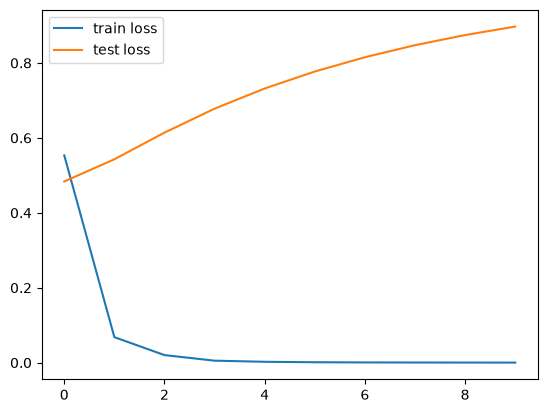

In [28]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

In [29]:
# Accuracy

n_correct = 0.
n_total = 0.
for inputs, targets in train_loader2:
  inputs, targets = inputs.to(device), targets.to(device)

  # Forward pass
  outputs = model(inputs)

  # Get prediction
  predictions = (outputs > 0)

  # update counts
  n_correct += (predictions == targets).sum().item()
  n_total += targets.shape[0]

train_acc = n_correct / n_total


n_correct = 0.
n_total = 0.
for inputs, targets in test_loader2:
  inputs, targets = inputs.to(device), targets.to(device)

  # Forward pass
  outputs = model(inputs)

  # Get prediction
  predictions = (outputs > 0)

  # update counts
  n_correct += (predictions == targets).sum().item()
  n_total += targets.shape[0]

test_acc = n_correct / n_total
print(f"Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}")

Train acc: 1.0000, Test acc: 0.9216


Compare the per-epoch `Duration` above with notebook 21's. There we pushed every
image through all of VGG16 on every epoch; here each epoch only touches a single
`Linear` layer over cached features, so it runs in milliseconds rather than
seconds — for comparable accuracy.

The catch is the one noted at the top: because the features are cached, you give up
data augmentation. With a small training set that can cost you some generalization,
which is exactly the tradeoff notebook 21 was paying for.